<a href="https://colab.research.google.com/github/mohit22617/CODINGSAMURAI/blob/main/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [182]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
df = pd.read_csv('telecom_churn.csv') # Ensure df is correctly loaded with 'Churn' column
X = df.drop(columns=['Churn'], axis=1)
Y = df['Churn']

print("Shape of X (features):")
display(X.head())
print("Shape of Y (target):")
display(Y.head())

Shape of X (features):


,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


Shape of Y (target):


,Churn
0,0
1,0
2,0
3,0
4,0


In [184]:
y.head(55)

,Churn
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


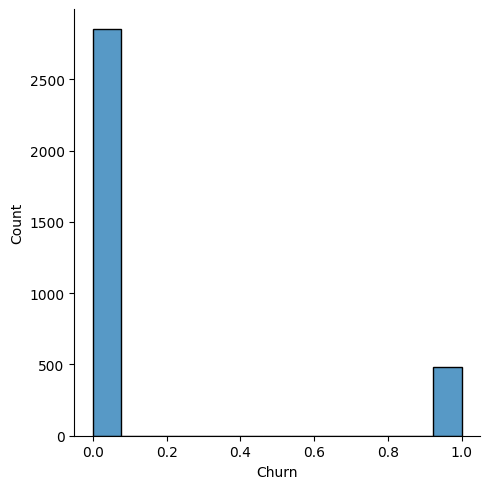

In [185]:
sns.displot(df['Churn'])
#highly imbalance column

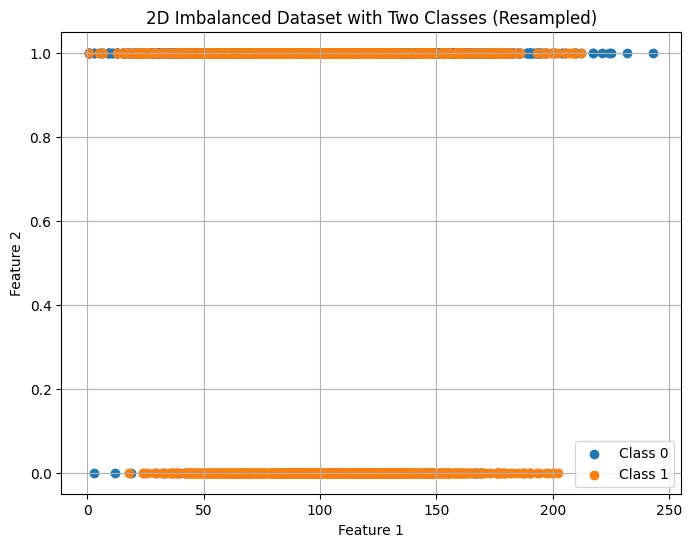

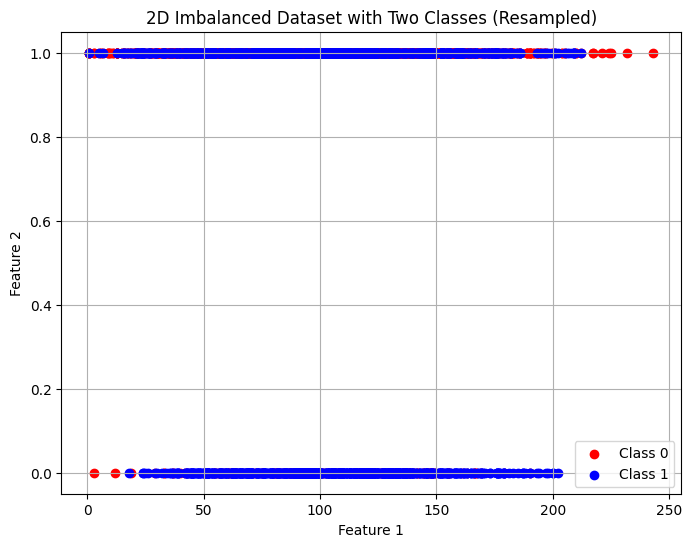

In [186]:
from imblearn.over_sampling import SMOTE

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Applying SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)

# Plotting (Displaying first two features)
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled_smote[y_resampled_smote == 0].iloc[:, 0], X_resampled_smote[y_resampled_smote == 0].iloc[:, 1], label='Class 0')
plt.scatter(X_resampled_smote[y_resampled_smote == 1].iloc[:, 0], X_resampled_smote[y_resampled_smote == 1].iloc[:, 1], label='Class 1')
plt.title('2D Imbalanced Dataset with Two Classes (Resampled)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Plotting (second plot - re-using logic, could be combined)
plt.figure(figsize=(8, 6))
plt.scatter(X_resampled_smote[y_resampled_smote == 0].iloc[:, 0], X_resampled_smote[y_resampled_smote == 0].iloc[:, 1], color='red', label='Class 0')
plt.scatter(X_resampled_smote[y_resampled_smote == 1].iloc[:, 0], X_resampled_smote[y_resampled_smote == 1].iloc[:, 1], color='blue', label='Class 1')
plt.title('2D Imbalanced Dataset with Two Classes (Resampled)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

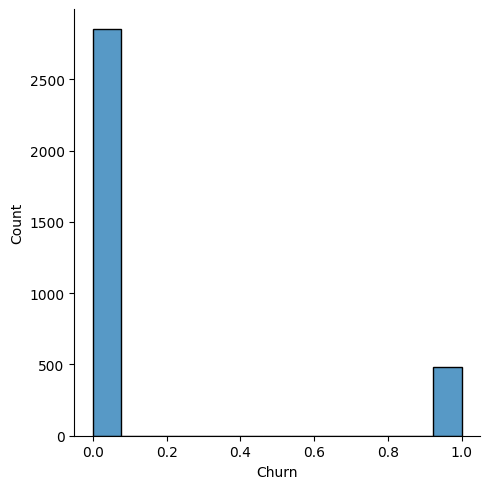

In [187]:
sns.displot(df['Churn'])
#highly imbalance column

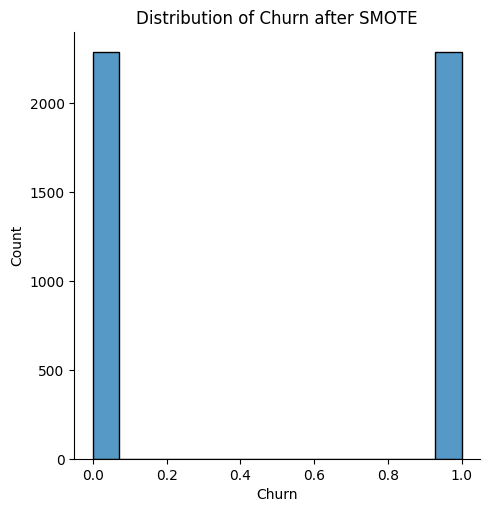

In [188]:
import seaborn as sns
sns.displot(y_resampled_smote)
plt.title('Distribution of Churn after SMOTE')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [189]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [190]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [191]:
X_train

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
817,1.000000,1.0,0.0,0.000000,0.222222,0.266801,0.459259,0.160042,0.450247,0.330
1373,0.442149,1.0,0.0,0.000000,0.444444,0.314187,0.555556,0.212343,0.532710,0.205
679,0.305785,0.0,0.0,0.000000,0.111111,0.631246,0.355556,0.526151,0.898846,0.435
56,0.578512,1.0,0.0,0.000000,0.111111,0.356979,0.503704,0.222803,0.494777,0.400
1993,0.351240,1.0,0.0,0.064815,0.000000,0.613728,0.488889,0.500000,0.732270,0.225
...,...,...,...,...,...,...,...,...,...,...
1095,0.433884,1.0,0.0,0.000000,0.111111,0.780586,0.666667,0.505230,0.545904,0.300
1130,0.500000,1.0,0.0,0.000000,0.111111,0.093337,0.237037,0.065900,0.496976,0.635
1294,0.268595,1.0,0.0,0.044444,0.111111,0.244113,0.340741,0.258368,0.720176,0.460
860,0.694215,1.0,0.0,0.000000,0.222222,0.507180,0.600000,0.316946,0.481583,0.495


In [192]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [193]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#
#

0.9310344827586207
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       566
           1       0.88      0.63      0.74       101

    accuracy                           0.93       667
   macro avg       0.91      0.81      0.85       667
weighted avg       0.93      0.93      0.93       667



In [194]:
def predict_churn(input_data):
    # Ensure input_data is a DataFrame with the same columns as X_train
    input_df = pd.DataFrame([input_data])

    # Scale the numerical columns using the fitted scaler
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    # Make prediction
    prediction = model.predict(input_df)

    # Return a more readable output
    if prediction[0] == 1:
        return "Churn"
    else:
        return "No Churn"

print("Function 'predict_churn' created successfully. You can now use it to make predictions.")

Function 'predict_churn' created successfully. You can now use it to make predictions.


In [195]:
predict_churn({
    'AccountWeeks': 119.00,
    'ContractRenewal': 1.0,
    'DataPlan': 0.0,
    'DataUsage': 0.00,
    'CustServCalls': 5.00,
    'DayMins': 0.266801,
    'DayCalls': 114.00,
    'MonthlyCharge': 47.00,
    'OverageFee': 11.57,
    'RoamMins': 8.80
})

'No Churn'

In [196]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']